# RFSV 波动率预测器

基于 Gatheral et al. (2014) "Volatility is Rough" 的预测框架，实现对数方差条件期望的黎曼和离散化预测，并与 AR、HAR 基准对比。

## 1. 导入与数据加载

In [1]:
import sys
sys.path.append('../models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HurstEstimator import HurstEstimator
from RFSVPredictor import (
    RFSVPredictor,
    predict_ar,
    predict_har,
    compute_p_ratio,
    estimate_nu_sq,
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['Arial Unicode MS']

In [2]:
# 加载方差代理数据
df = pd.read_csv('../data/variance_proxy_20230101_20251231.csv')
# df = pd.read_csv('../data/variance_proxy_20220701_20231231.csv') # 很差！！！

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# log σ² 序列（预测公式使用 log-variance）
log_var = np.log(df['rv_uz'])
var_series = df['rv_uz']

print(f"数据范围: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"交易日数: {len(df)}")

数据范围: 2023-01-03 ~ 2025-12-31
交易日数: 727


## 2. 参数估计：H 与 ν²（单一回归）

- 使用 `HurstEstimator` 对 `log(σ)=0.5*log(rv_uz)` 做 `q=2` 变差回归
- 该回归一次性得到：
  - `H = slope / 2`
  - `ν² = exp(intercept)`
- 不再重复调用 `RFSVPredictor` 中的 `estimate_nu_sq`，避免同一统计量重复估计

In [3]:
# 估计 Hurst 指数 H（输入为 log σ = 0.5*log(rv_uz)）
hurst = HurstEstimator()
log_vol_series = 0.5 * np.log(df['rv_uz'])   # log(σ)

START_IDX = 500  # 使用前500个值作为估计参数的素材
H, h_info = hurst.estimate_hurst_variogram(log_vol_series[:START_IDX], q=2.0)  
print(f"Hurst 指数 H = {H:.4f} (R² = {h_info['r_squared']:.4f})")
print(f"二阶矩回归截距 {h_info['intercept']:.4f}, ν² = {np.exp(h_info['intercept'])} ")

nu_sq = np.exp(h_info['intercept'])

Hurst 指数 H = 0.0979 (R² = 0.9125)
二阶矩回归截距 -3.1368, ν² = 0.0434213463736186 


In [ ]:
nu_sq_2, dic = estimate_nu_sq(log_var[:START_IDX], 250) # 从RFSVPredictor引入的方法
for key in dic.keys():
    print(f"{key}: {dic[key]}")

slope: 0.16637984946320727
intercept: -3.030639495569362
r_squared: 0.647619669268301
nu_sq: 0.04828475036690048
n_deltas: 250


## 3. RFSV 滚动预测

对 Δ = 1, 5, 20 日分别进行预测，若使用 500 日 warm-up 与论文一致。

In [5]:
deltas = [1, 5, 20]
rfsv_preds = {}

for delta in deltas:
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=3)
    preds = predictor.predict_rolling(log_var.values, start_idx=START_IDX)
    rfsv_preds[delta] = preds
    print(f"Δ={delta}: {len(preds)} 个预测值")

Δ=1: 226 个预测值
Δ=5: 222 个预测值
Δ=20: 207 个预测值


In [6]:
# # 三个 delta 下不同 window_ratio 的预测效果检测
# START_IDX = 500
# deltas = [1, 5, 20]
# window_ratios = np.linspace(0.1, 3, 20)  # 测试窗口系数
# mean_log_var = np.nanmean(log_var.values)

# results_wr = []  # (delta, window_ratio, P)
# rfsv_preds = {}  # 最优 window_ratio 的预测，供后续对比

# for delta in deltas:
#     best_p, best_wr, best_preds = np.inf, None, None
#     for wr in window_ratios:
#         predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=wr)
#         preds = predictor.predict_rolling(log_var.values, start_idx=START_IDX)
#         actual = log_var.values[START_IDX + delta :]
#         p = compute_p_ratio(actual, preds, mean_log_var)
#         results_wr.append({'Δ': delta, 'window_ratio': wr, 'P': p})
#         if p < best_p:
#             best_p, best_wr, best_preds = p, wr, preds
#     rfsv_preds[delta] = best_preds
#     print(f"Δ={delta}: 最优 window_ratio={best_wr:.2f}, P={best_p:.4f}")

# df_wr = pd.DataFrame(results_wr)
# pivot_wr = df_wr.pivot(index='Δ', columns='window_ratio', values='P')
# print("\nP 值随 window_ratio 变化（行=Δ，列=window_ratio）:")
# print(pivot_wr.round(3).to_string())

In [7]:
# # 可视化：各 Δ 下 P 随 window_ratio 的变化
# fig, ax = plt.subplots(figsize=(8, 5))
# for delta in deltas:
#     sub = df_wr[df_wr['Δ'] == delta]
#     ax.plot(sub['window_ratio'], sub['P'], 'o-', label=f'Δ={delta}')
# ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
# ax.set_xlabel('window_ratio (r)')
# ax.set_ylabel('P (MSE 比例)')
# ax.set_title('RFSV 预测 P 值随 window_ratio 变化')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

## 4. AR 与 HAR 基准

- **AR(5), AR(10)**：滚动 500 日估计系数
- **HAR(3)**：1 日、5 日、20 日均值作为 regressor

In [8]:
# AR 与 HAR 预测
ar5_preds = {}
ar10_preds = {}
har_preds = {}

for delta in deltas:
    ar5_preds[delta] = predict_ar(log_var.values, delta=delta, p=5, train_window=START_IDX)
    ar10_preds[delta] = predict_ar(log_var.values, delta=delta, p=10, train_window=START_IDX)
    har_preds[delta] = predict_har(log_var.values, delta=delta, train_window=START_IDX)

## 5. 评估指标 P（MSE 比例）

### P 值的含义

P 是 Gatheral (2014) 论文中用于比较波动率预测模型性能的指标，定义为：

$$P = \frac{\sum_k \big(\log\sigma^2_{k+\Delta} - \widehat{\log\sigma^2}_{k+\Delta}\big)^2}{\sum_k \big(\log\sigma^2_{k+\Delta} - \overline{\log\sigma^2}\big)^2}$$

即 **预测的均方误差 (MSE)** 与 **真实值围绕样本均值的方差** 之比。

- **P < 1**：预测优于 naive 基准（用样本均值作为预测）；P 越小，预测越准
- **P = 1**：与 naive 基准相当
- **P > 1**：预测比 naive 更差

不同模型在同一 Δ 下的 P 值可直接比较，P 更小的模型预测效果更好。

In [9]:
# 对齐的 actual 序列：log σ²_{k+Δ}，k 从 START_IDX 到 n-delta-1
mean_log_var = np.nanmean(log_var.values)

results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    # 预测序列长度 = n - START_IDX - delta
    p_rfsv = compute_p_ratio(actual, rfsv_preds[delta], mean_log_var)
    p_ar5 = compute_p_ratio(actual, ar5_preds[delta], mean_log_var)
    p_ar10 = compute_p_ratio(actual, ar10_preds[delta], mean_log_var)
    p_har = compute_p_ratio(actual, har_preds[delta], mean_log_var)
    results.append({
        'Δ': delta,
        'AR(5)': p_ar5,
        'AR(10)': p_ar10,
        'HAR(3)': p_har,
        'RFSV': p_rfsv,
    })

df_results = pd.DataFrame(results).set_index('Δ')
print("Table 5.1 风格 - log-variance 预测 P 值（沪深300）")
print(df_results.round(3).to_string())

Table 5.1 风格 - log-variance 预测 P 值（沪深300）
    AR(5)  AR(10)  HAR(3)   RFSV
Δ                               
1   0.506   0.505   0.502  0.604
5   0.801   0.794   0.783  0.880
20  1.005   1.022   1.017  1.354


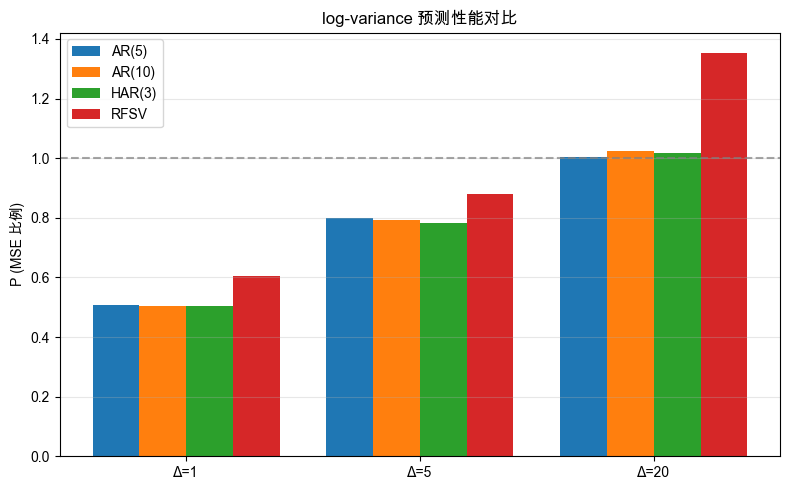

In [10]:
# 可视化：各模型 P 值对比
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(deltas))
width = 0.2

ax.bar(x - 1.5*width, df_results['AR(5)'], width, label='AR(5)')
ax.bar(x - 0.5*width, df_results['AR(10)'], width, label='AR(10)')
ax.bar(x + 0.5*width, df_results['HAR(3)'], width, label='HAR(3)')
ax.bar(x + 1.5*width, df_results['RFSV'], width, label='RFSV')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'Δ={d}' for d in deltas])
ax.set_ylabel('P (MSE 比例)')
ax.set_title('log-variance 预测性能对比')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 预测路径与真实波动率走势

对比各模型预测的波动率路径与真实实现波动率的时间序列。

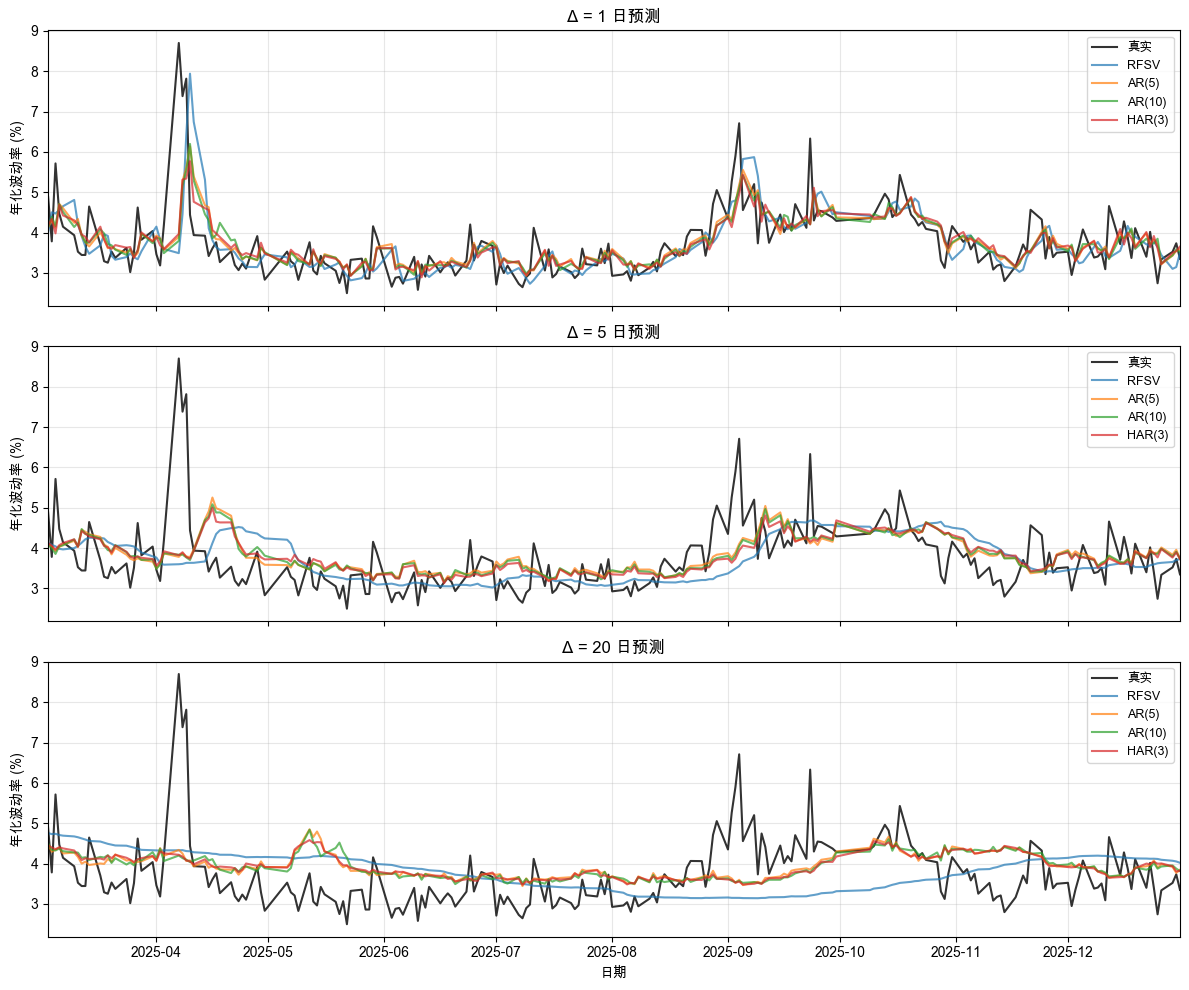

In [11]:
# 波动率预测路径与真实走势（年化波动率 %）
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
n = len(log_var)

for idx, delta in enumerate(deltas):
    ax = axes[idx]
    dates = df.index[START_IDX + delta : n]
    # 真实年化波动率
    actual_vol = np.sqrt(np.exp(log_var.values[START_IDX + delta : n]) * 252) * 100
    ax.plot(dates, actual_vol, 'k-', alpha=0.8, linewidth=1.5, label='真实')
    # 各模型预测（log 预测转年化波动率）
    rfsv_vol = np.sqrt(np.exp(rfsv_preds[delta]) * 252) * 100
    ar5_vol = np.sqrt(np.exp(ar5_preds[delta]) * 252) * 100
    ar10_vol = np.sqrt(np.exp(ar10_preds[delta]) * 252) * 100
    har_vol = np.sqrt(np.exp(har_preds[delta]) * 252) * 100
    ax.plot(dates, rfsv_vol, alpha=0.7, label='RFSV')
    ax.plot(dates, ar5_vol, alpha=0.7, label='AR(5)')
    ax.plot(dates, ar10_vol, alpha=0.7, label='AR(10)')
    ax.plot(dates, har_vol, alpha=0.7, label='HAR(3)')
    ax.set_ylabel('年化波动率 (%)')
    ax.set_title(f'Δ = {delta} 日预测')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(dates[0], dates[-1])

axes[-1].set_xlabel('日期')
plt.tight_layout()
plt.show()

## 6. 方差预测（公式 5.2）

σ̂² = exp{ log σ̂² + 2cν²Δ^{2H} }，与 AR/HAR 在方差空间对比。

In [12]:
# 方差预测：RFSV 用修正公式，AR/HAR 对 log 预测取 exp
def compute_p_ratio_var(actual_var, pred_var, mean_var):
    """方差空间的 P 比例"""
    mask = ~(np.isnan(actual_var) | np.isnan(pred_var) | (actual_var <= 0) | (pred_var <= 0))
    if mask.sum() < 2:
        return np.nan
    a, p = actual_var[mask], pred_var[mask]
    mse = np.mean((a - p) ** 2)
    var_term = np.mean((a - mean_var) ** 2)
    return mse / var_term if var_term > 1e-12 else np.nan

mean_var = np.nanmean(var_series.values)
results_var = []

for delta in deltas:
    n = len(var_series)
    actual_v = var_series.values[START_IDX + delta : n]
    
    # RFSV 方差预测
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=1.0)
    rfsv_var_preds = []
    for t in range(START_IDX, n - delta):
        rfsv_var_preds.append(predictor.predict_variance(var_series.values, t))
    rfsv_var_preds = np.array(rfsv_var_preds)
    
    # AR/HAR 在 log 空间预测，exp 得到方差
    ar5_var = np.exp(ar5_preds[delta])
    ar10_var = np.exp(ar10_preds[delta])
    har_var = np.exp(har_preds[delta])
    
    results_var.append({
        'Δ': delta,
        'AR(5)': compute_p_ratio_var(actual_v, ar5_var, mean_var),
        'AR(10)': compute_p_ratio_var(actual_v, ar10_var, mean_var),
        'HAR(3)': compute_p_ratio_var(actual_v, har_var, mean_var),
        'RFSV': compute_p_ratio_var(actual_v, rfsv_var_preds, mean_var),
    })

df_results_var = pd.DataFrame(results_var).set_index('Δ')
print("Table 5.2 风格 - 方差预测 P 值（沪深300）")
print(df_results_var.round(3).to_string())

Table 5.2 风格 - 方差预测 P 值（沪深300）
    AR(5)  AR(10)  HAR(3)   RFSV
Δ                               
1   0.601   0.609   0.601  0.753
5   0.858   0.851   0.844  1.108
20  0.893   0.911   0.905  1.128


### RFSV 效果弱于基准的原因诊断

从预测路径可视化中观察到，RFSV 能捕捉波动率的大幅波动，但往往伴随一定滞后。然而在 P 值上，RFSV 却弱于 AR 和 HAR 基准。本节通过多维度诊断指标探究其原因。

**待检验假设：**
- **滞后效应**：RFSV 预测系统性滞后 k 日，导致在波动率突变时预测误差较大
- **高波动 regime**：在高波动时期，RFSV 的误差更大，而 AR/HAR 更稳健
- **误差结构**：RFSV 的误差与波动水平正相关，MSE 对大误差惩罚重，拉高 P 值

In [13]:
# 诊断指标计算
from scipy.stats import skew, kurtosis

print("=" * 70)
print("诊断 1：滞后检验 - RFSV 预测前移 k 日后的 P 值")
print("=" * 70)
lag_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for k in range(4):
        if k == 0:
            p_lag = compute_p_ratio(actual, rfsv_preds[delta], mean_log_var)
        else:
            # 预测前移 k 日：预测去头 k 个，真实值去尾 k 个
            rfsv_shifted = rfsv_preds[delta][k:]
            actual_shifted = actual[:-k]
            p_lag = compute_p_ratio(actual_shifted, rfsv_shifted, mean_log_var)
        lag_results.append({'Δ': delta, 'lag_k': k, 'P(k)': p_lag})

df_lag = pd.DataFrame(lag_results)
lag_pivot = df_lag.pivot(index='Δ', columns='lag_k', values='P(k)')
lag_pivot.columns = [f'k={int(c)}' for c in lag_pivot.columns]
print(lag_pivot.round(3).to_string())
print()

print("=" * 70)
print("诊断 2：高/低波动 regime 分解（按 actual 80% 分位数划分）")
print("=" * 70)
regime_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    threshold = np.percentile(actual, 80)
    high_mask = actual >= threshold
    low_mask = ~high_mask
    
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]), 
                          ('HAR(3)', har_preds[delta])]:
        mask_valid = ~(np.isnan(actual) | np.isnan(preds))
        high_valid = high_mask & mask_valid
        low_valid = low_mask & mask_valid
        
        mse_high = np.mean((actual[high_valid] - preds[high_valid])**2) if high_valid.sum() > 0 else np.nan
        mse_low = np.mean((actual[low_valid] - preds[low_valid])**2) if low_valid.sum() > 0 else np.nan
        
        regime_results.append({
            'Δ': delta, '模型': model, 
            'MSE_高波动': mse_high, 'n_高': high_valid.sum(),
            'MSE_低波动': mse_low, 'n_低': low_valid.sum()
        })

df_regime = pd.DataFrame(regime_results)
for delta in deltas:
    print(f"\nΔ = {delta} 日:")
    subset = df_regime[df_regime['Δ'] == delta][['模型', 'MSE_高波动', 'n_高', 'MSE_低波动', 'n_低']]
    print(subset.round(4).to_string(index=False))

print("\n" + "=" * 70)
print("诊断 3：误差与波动水平的相关性（error = actual - pred）")
print("=" * 70)
corr_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]),
                          ('AR(10)', ar10_preds[delta]),
                          ('HAR(3)', har_preds[delta])]:
        mask = ~(np.isnan(actual) | np.isnan(preds))
        if mask.sum() < 10:
            continue
        errors = actual[mask] - preds[mask]
        corr_abs = np.corrcoef(np.abs(errors), actual[mask])[0, 1]
        corr_sq = np.corrcoef(errors**2, actual[mask])[0, 1]
        corr_results.append({'Δ': delta, '模型': model, 'corr(|error|, actual)': corr_abs, 'corr(error², actual)': corr_sq})

df_corr = pd.DataFrame(corr_results)
for delta in deltas:
    print(f"\nΔ = {delta} 日:")
    subset = df_corr[df_corr['Δ'] == delta][['模型', 'corr(|error|, actual)', 'corr(error², actual)']]
    print(subset.round(3).to_string(index=False))

print("\n" + "=" * 70)
print("诊断 4：误差分布统计（偏度、峰度）")
print("=" * 70)
dist_results = []
for delta in deltas:
    n = len(log_var)
    actual = log_var.values[START_IDX + delta : n]
    for model, preds in [('RFSV', rfsv_preds[delta]), 
                          ('AR(5)', ar5_preds[delta]),
                          ('HAR(3)', har_preds[delta])]:
        mask = ~(np.isnan(actual) | np.isnan(preds))
        if mask.sum() < 10:
            continue
        errors = actual[mask] - preds[mask]
        sk = skew(errors)
        kt = kurtosis(errors)
        dist_results.append({'Δ': delta, '模型': model, '偏度': sk, '峰度': kt})

df_dist = pd.DataFrame(dist_results)
for delta in deltas:
    print(f"\nΔ = {delta} 日:")
    subset = df_dist[df_dist['Δ'] == delta][['模型', '偏度', '峰度']]
    print(subset.round(3).to_string(index=False))

诊断 1：滞后检验 - RFSV 预测前移 k 日后的 P 值
      k=0    k=1    k=2    k=3
Δ                             
1   0.604  0.325  0.152  0.215
5   0.880  0.849  0.812  0.774
20  1.354  1.335  1.317  1.300

诊断 2：高/低波动 regime 分解（按 actual 80% 分位数划分）

Δ = 1 日:
    模型  MSE_高波动  n_高  MSE_低波动  n_低
  RFSV   0.2293   46   0.0703  180
 AR(5)   0.1791   46   0.0622  180
HAR(3)   0.1840   46   0.0602  180

Δ = 5 日:
    模型  MSE_高波动  n_高  MSE_低波动  n_低
  RFSV   0.3513   45   0.0998  177
 AR(5)   0.2859   45   0.0995  177
HAR(3)   0.2931   45   0.0939  177

Δ = 20 日:
    模型  MSE_高波动  n_高  MSE_低波动  n_低
  RFSV   0.5335   42   0.1713  165
 AR(5)   0.3059   42   0.1500  165
HAR(3)   0.3198   42   0.1493  165

诊断 3：误差与波动水平的相关性（error = actual - pred）

Δ = 1 日:
    模型  corr(|error|, actual)  corr(error², actual)
  RFSV                  0.371                 0.401
 AR(5)                  0.260                 0.364
AR(10)                  0.276                 0.375
HAR(3)                  0.305                 0.403

Δ = 5 日: